# EDA — Logements sociaux financés à Paris
Urban Data Explorer · Open Data Paris

> 1 ligne = 1 programme de logements sociaux financés.


## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


## 1. Chargement

In [2]:
FILE = '../brute/Nouveau dossier/logements-sociaux-finances-a-paris.csv'

df = pd.read_csv(FILE, sep=None, engine='python', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Identifiant livraison'              : 'id',
    'Adresse du programme'               : 'adresse',
    'Code postal'                        : 'code_postal',
    'Ville'                              : 'ville',
    'Année du financement - agrément'    : 'annee',
    'Bailleur social'                    : 'bailleur',
    'Nombre total de logements financés' : 'nb_logements',
    'Dont nombre de logements PLA I'     : 'nb_plai',
    'Dont nombre de logements PLUS'      : 'nb_plus',
    'Dont nombre de logements PLUS CD'   : 'nb_plus_cd',
    'Dont nombre de logements PLS'       : 'nb_pls',
    'Mode de réalisation'                : 'mode_realisation',
    'Commentaires'                       : 'commentaires',
    'Arrondissement'                     : 'arrondissement',
    'Nature de programme'                : 'nature_programme',
    'Coordonnée en X (L93)'              : 'x_l93',
    'Coordonnée en Y (L93)'              : 'y_l93',
})

df['annee']          = pd.to_numeric(df['annee'], errors='coerce')
df['nb_logements']   = pd.to_numeric(df['nb_logements'], errors='coerce')
df['nb_plai']        = pd.to_numeric(df['nb_plai'], errors='coerce')
df['nb_plus']        = pd.to_numeric(df['nb_plus'], errors='coerce')
df['nb_plus_cd']     = pd.to_numeric(df['nb_plus_cd'], errors='coerce')
df['nb_pls']         = pd.to_numeric(df['nb_pls'], errors='coerce')
df['arrondissement'] = pd.to_numeric(df['arrondissement'], errors='coerce')

print(f'Lignes : {len(df):,}')
print(f'Période : {int(df["annee"].min())} → {int(df["annee"].max())}')
print(f'Total logements financés : {df["nb_logements"].sum():,.0f}')


Lignes : 4,174
Période : 2001 → 2024
Total logements financés : 126,544


## 2. Valeurs manquantes

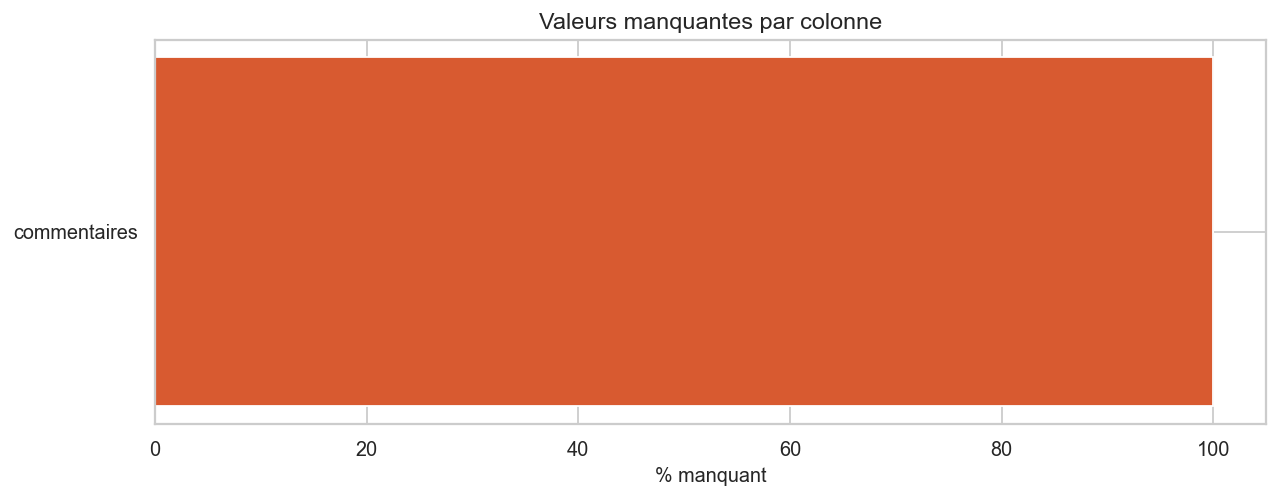

In [3]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.4)))
colors = ['#D85A30' if v > 70 else '#BA7517' if v > 30 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne')
plt.tight_layout()
plt.show()


## 3. Évolution historique — logements financés par année

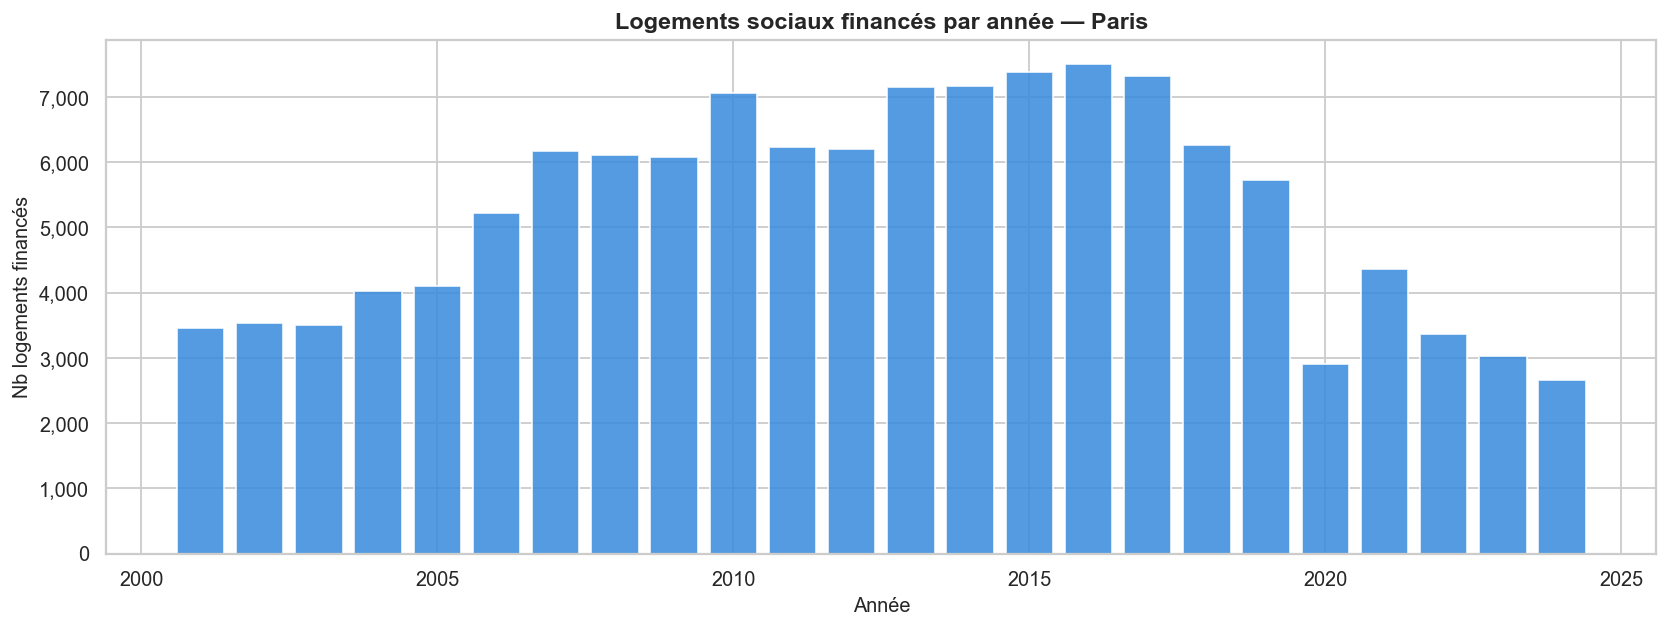

 annee  nb_logements
  2001          3465
  2002          3530
  2003          3500
  2004          4032
  2005          4095
  2006          5229
  2007          6165
  2008          6111
  2009          6081
  2010          7064
  2011          6233
  2012          6197
  2013          7151
  2014          7166
  2015          7388
  2016          7502
  2017          7318
  2018          6257
  2019          5723
  2020          2908
  2021          4364
  2022          3373
  2023          3035
  2024          2657


In [4]:
par_annee = (df.groupby('annee')['nb_logements']
               .sum()
               .reset_index(name='nb_logements'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(par_annee['annee'], par_annee['nb_logements'],
       color='#378ADD', alpha=0.85, edgecolor='white')
ax.set_xlabel('Année')
ax.set_ylabel('Nb logements financés')
ax.set_title('Logements sociaux financés par année — Paris', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(par_annee.to_string(index=False))


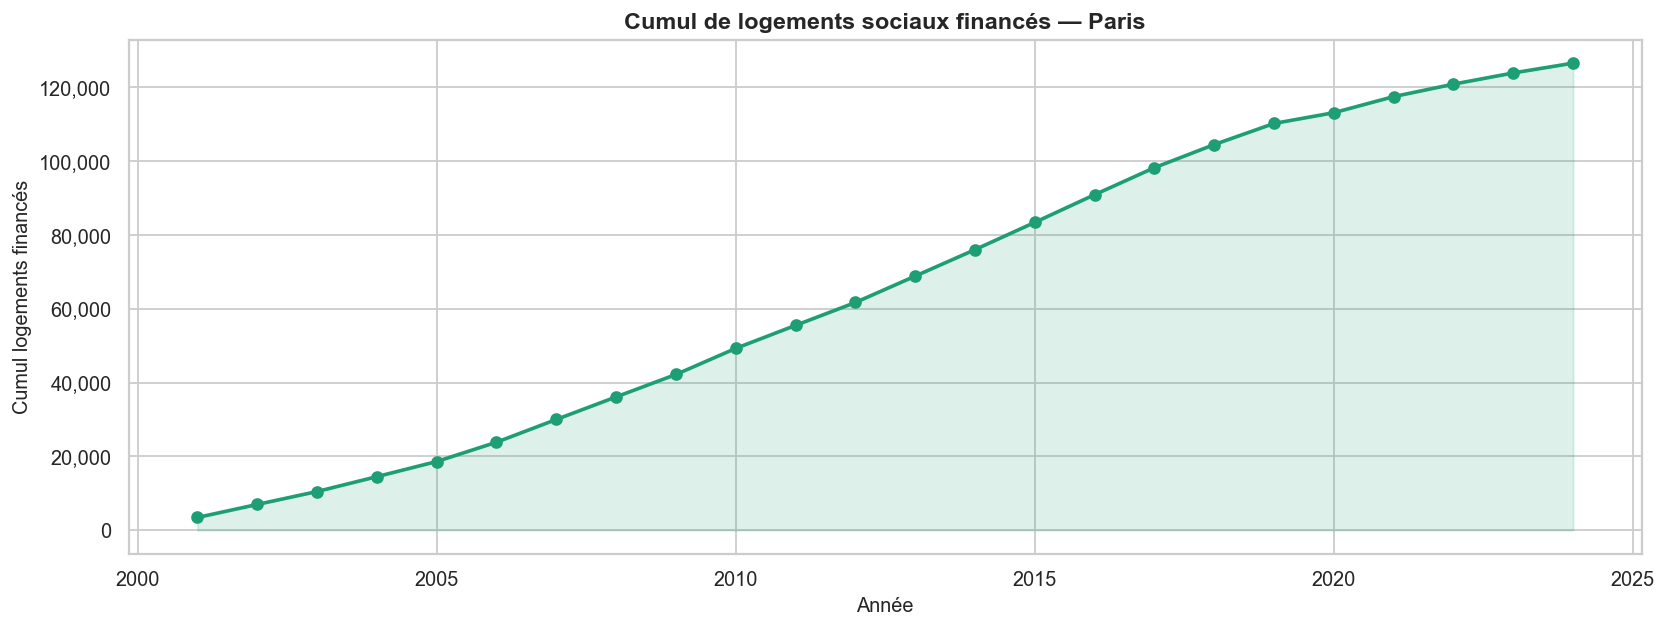

In [5]:
par_annee['cumul'] = par_annee['nb_logements'].cumsum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(par_annee['annee'], par_annee['cumul'],
        marker='o', color='#1D9E75', linewidth=2)
ax.fill_between(par_annee['annee'], par_annee['cumul'], alpha=0.15, color='#1D9E75')
ax.set_xlabel('Année')
ax.set_ylabel('Cumul logements financés')
ax.set_title('Cumul de logements sociaux financés — Paris', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


## 4. Répartition par arrondissement

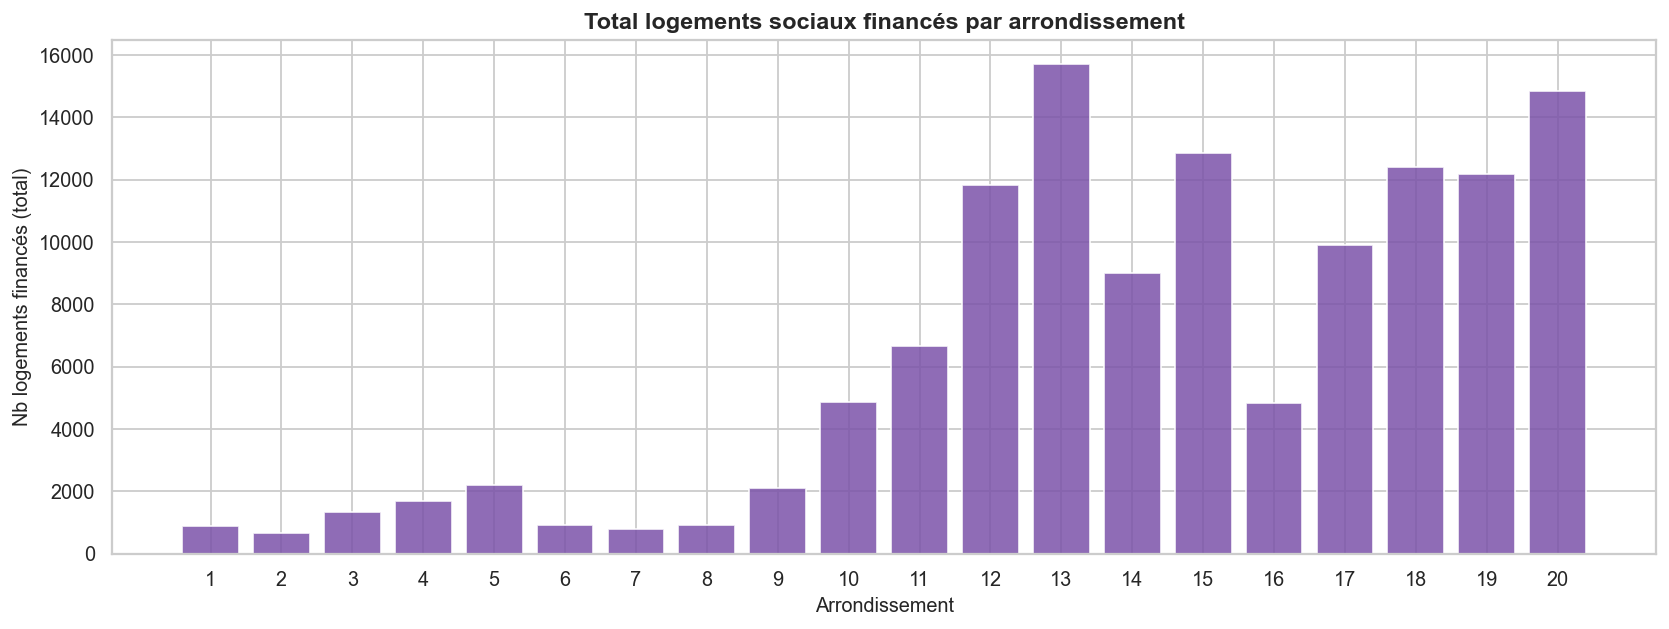

In [6]:
par_arrond = (df.groupby('arrondissement')['nb_logements']
                .sum()
                .reset_index(name='nb_logements')
                .sort_values('arrondissement'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(par_arrond['arrondissement'].astype(int).astype(str),
       par_arrond['nb_logements'],
       color='#7B52A9', alpha=0.85, edgecolor='white')
ax.set_xlabel('Arrondissement')
ax.set_ylabel('Nb logements financés (total)')
ax.set_title('Total logements sociaux financés par arrondissement', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Heatmap arrondissement × année

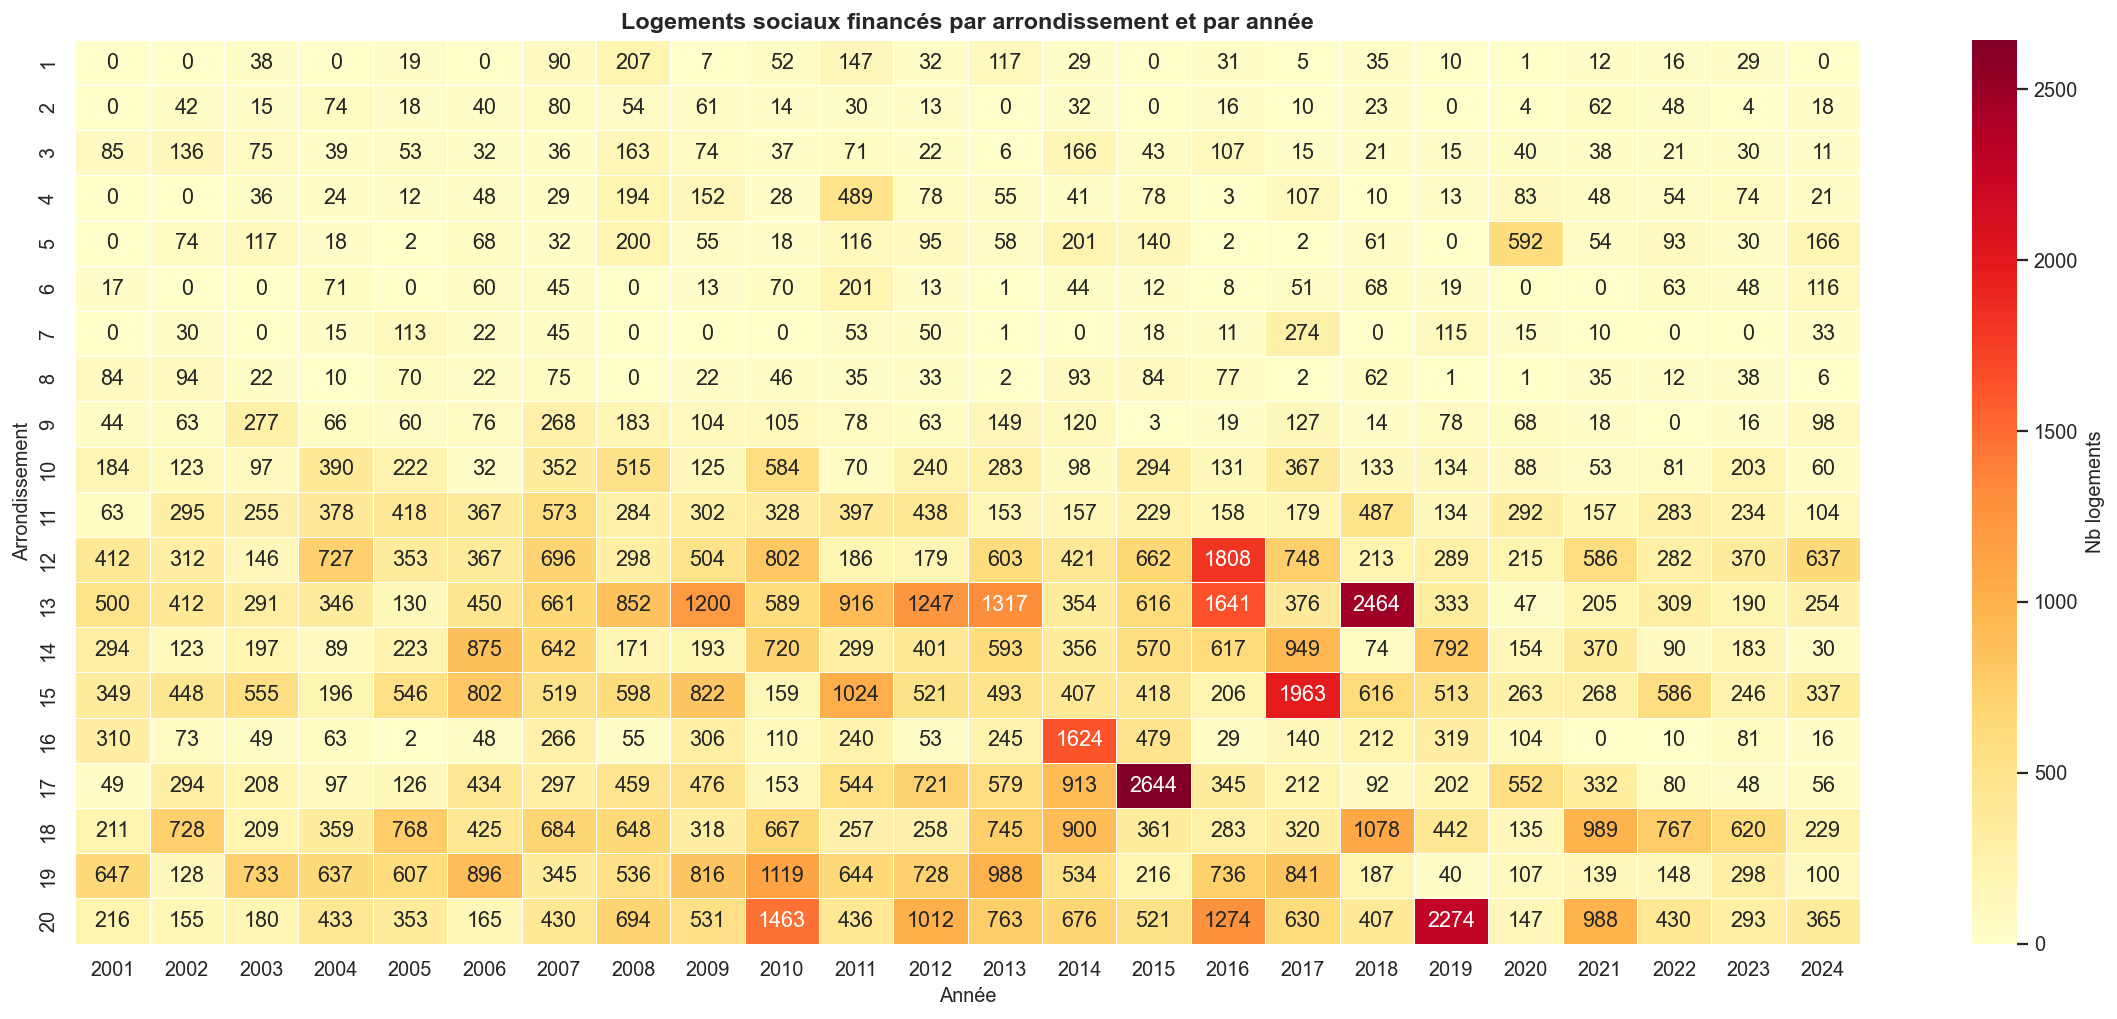

In [7]:
pivot = (df.groupby(['arrondissement', 'annee'])['nb_logements']
           .sum()
           .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Nb logements'})
ax.set_title('Logements sociaux financés par arrondissement et par année', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Arrondissement')
plt.tight_layout()
plt.show()


## 6. Répartition par type de financement (PLAI / PLUS / PLS)

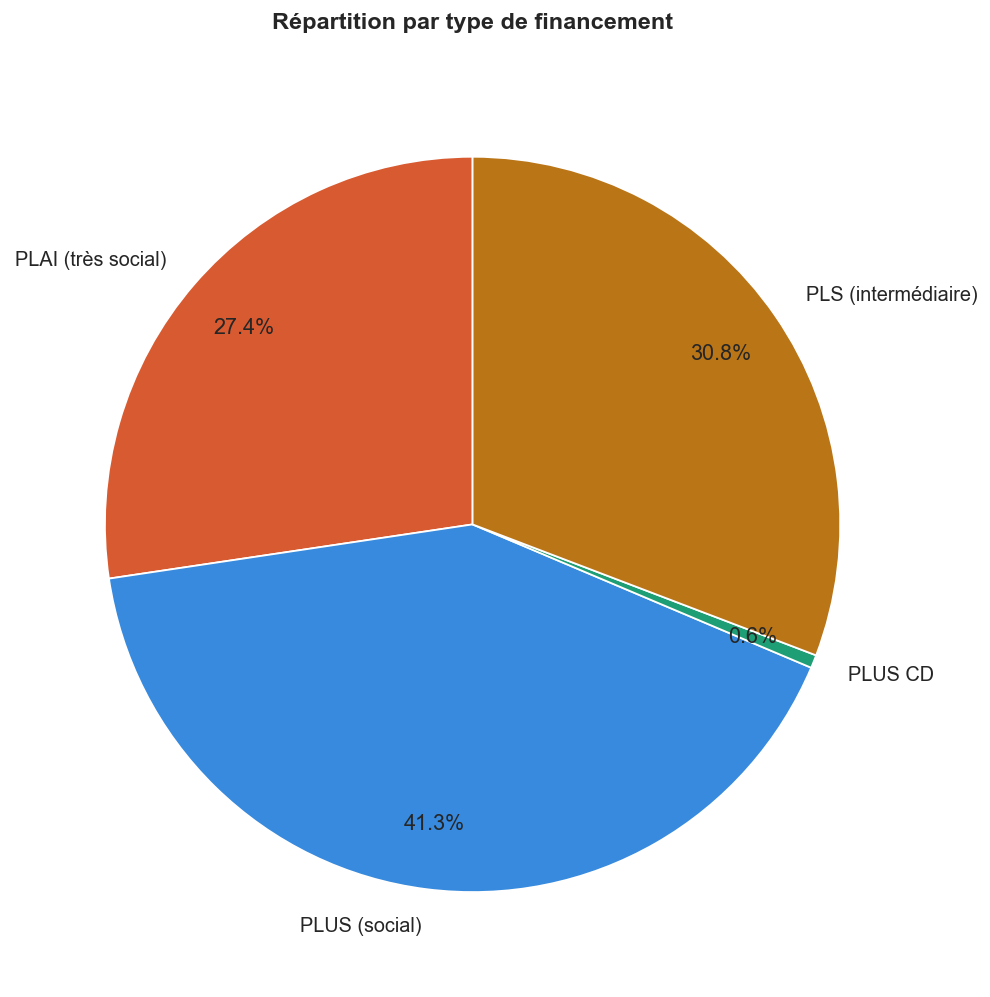

PLAI (très social)        : 34,616
PLUS (social)             : 52,228
PLUS CD                   : 730
PLS (intermédiaire)       : 38,970


In [8]:
totaux = {
    'PLAI (très social)'  : df['nb_plai'].sum(),
    'PLUS (social)'       : df['nb_plus'].sum(),
    'PLUS CD'             : df['nb_plus_cd'].sum(),
    'PLS (intermédiaire)' : df['nb_pls'].sum(),
}

fig, ax = plt.subplots(figsize=(8, 8))
wedge_colors = ['#D85A30', '#378ADD', '#1D9E75', '#BA7517']
ax.pie(totaux.values(), labels=totaux.keys(),
       autopct='%1.1f%%', colors=wedge_colors,
       startangle=90, pctdistance=0.82)
ax.set_title('Répartition par type de financement', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

for k, v in totaux.items():
    print(f'{k:25s} : {v:,.0f}')


## 7. Mode de réalisation

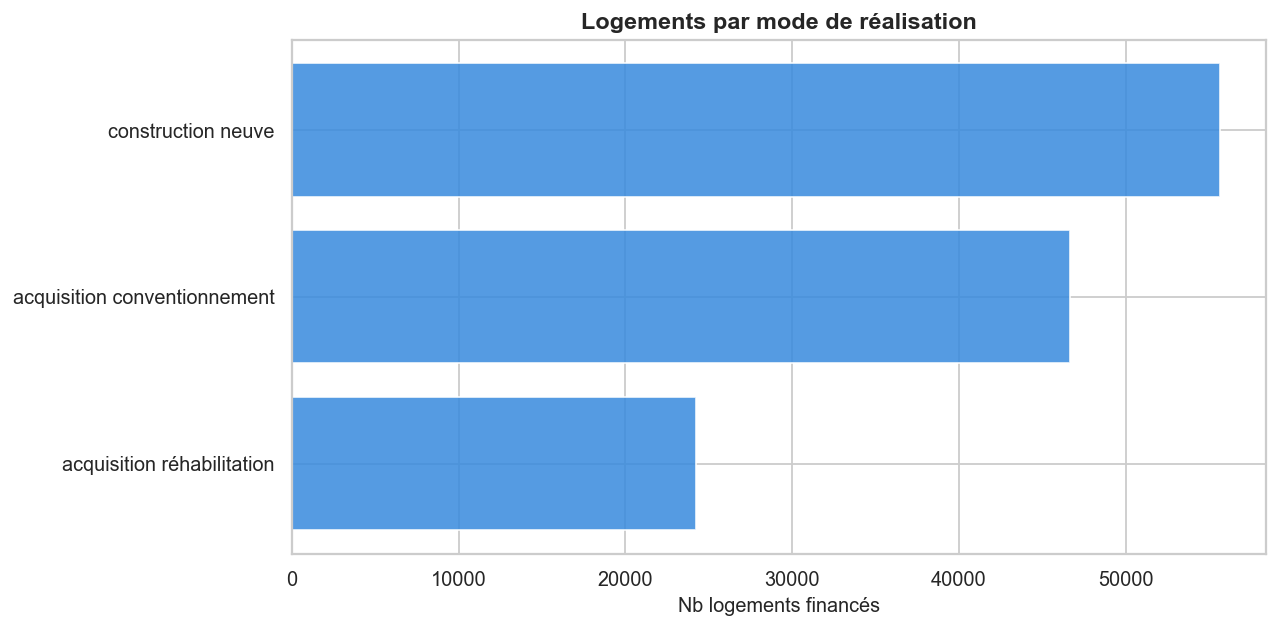

In [9]:
mode = (df.groupby('mode_realisation')['nb_logements']
          .sum()
          .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mode.index, mode.values, color='#378ADD', alpha=0.85, edgecolor='white')
ax.set_xlabel('Nb logements financés')
ax.set_title('Logements par mode de réalisation', fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Top bailleurs sociaux

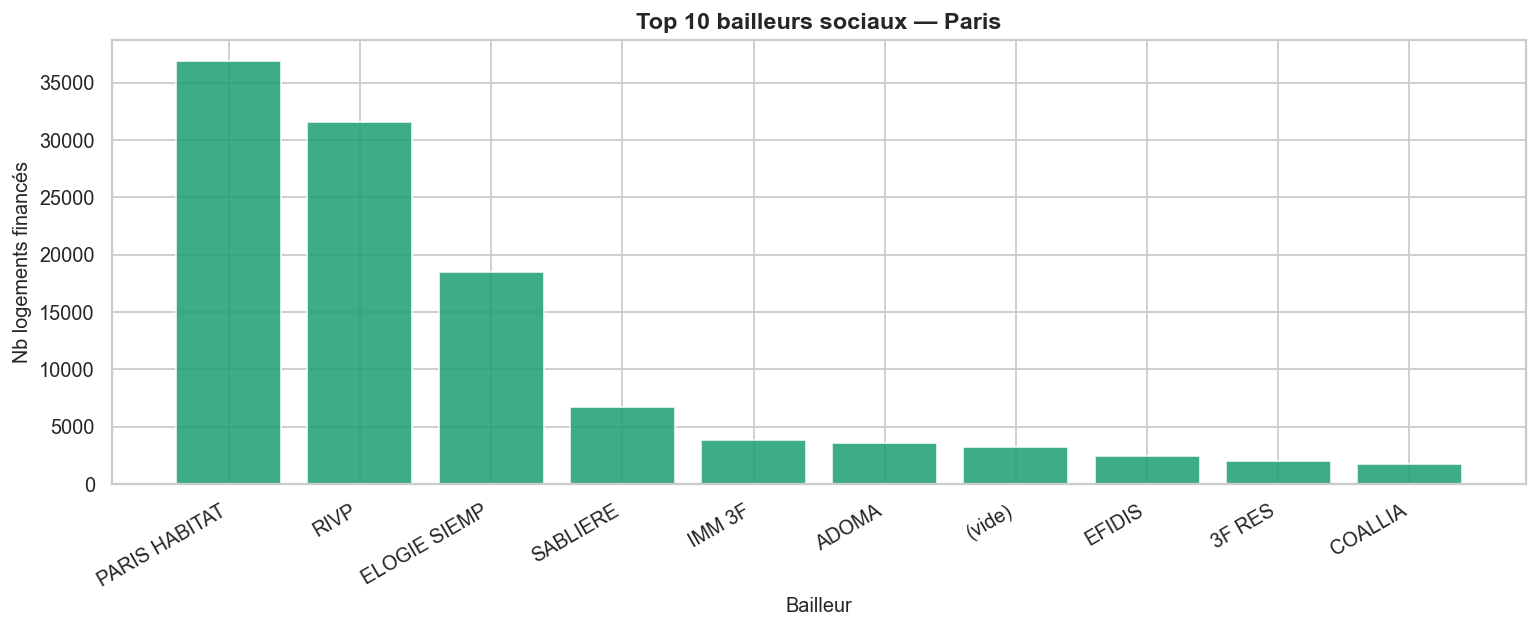

In [10]:
top_bailleurs = (df.groupby('bailleur')['nb_logements']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_bailleurs.index, top_bailleurs.values,
       color='#1D9E75', alpha=0.85, edgecolor='white')
ax.set_xlabel('Bailleur')
ax.set_ylabel('Nb logements financés')
ax.set_title('Top 10 bailleurs sociaux — Paris', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
